In [17]:
install.packages("HSAUR3")
install.packages("geepack")

# Load data
data("respiratory", package = "HSAUR3")

# Quick look
head(respiratory)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,centre,treatment,gender,age,status,month,subject
,<fct>,<fct>,<fct>,<dbl>,<fct>,<ord>,<fct>
1,1,placebo,female,46,poor,0,1
112,1,placebo,female,46,poor,1,1
223,1,placebo,female,46,poor,2,1
334,1,placebo,female,46,poor,3,1
445,1,placebo,female,46,poor,4,1
2,1,placebo,female,28,poor,0,2


In [18]:
# Example GEE Model (Binomial family, Exchangeable correlation)
library(geepack)


# Using 'status' as the outcome variable, which seems appropriate for 'respiratory' data.
# Convert 'status' to a numeric variable (0/1) for binomial family, mapping 'poor' to 0 and 'good' to 1.
respiratory$status_numeric <- ifelse(respiratory$status == "poor", 0, 1)

model_resp <- geeglm(status_numeric ~ treatment + age + gender + month,
                     id = subject,
                     data = respiratory,
                     family = binomial,
                     corstr = "exchangeable")
summary(model_resp)


Call:
geeglm(formula = status_numeric ~ treatment + age + gender + 
    month, family = binomial, data = respiratory, id = subject, 
    corstr = "exchangeable")

 Coefficients:
                   Estimate  Std.err Wald Pr(>|W|)   
(Intercept)         0.08901  0.42151 0.04   0.8328   
treatmenttreatment  0.77750  0.29914 6.76   0.0093 **
age                -0.00959  0.01190 0.65   0.4205   
gendermale         -0.00916  0.39058 0.00   0.9813   
month.L             0.21456  0.15877 1.83   0.1766   
month.Q            -0.32379  0.14403 5.05   0.0246 * 
month.C             0.10728  0.14193 0.57   0.4497   
month^4            -0.23216  0.12273 3.58   0.0585 . 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation structure = exchangeable 
Estimated Scale Parameters:

            Estimate Std.err
(Intercept)    0.998  0.0343
  Link = identity 

Estimated Correlation Parameters:
      Estimate Std.err
alpha    0.465   0.055
Number of clusters:   111  Maximum cluster

---

### **Research Report: Analysis of Treatment Efficacy and Temporal Trends**

**Objective:**  
To evaluate the effect of Treatment on the status while adjusting for patient demographics (age and gender) and accounting for temporal changes over a 5-month period.

**Methodology:**  
Data from 111 subjects (maximum cluster size of 5 observations per subject) were analyzed using a Generalized Estimating Equation (GEE) model. To account for the longitudinal nature of the data and the correlation between repeated measurements within the same subject, an **exchangeable correlation structure** was employed. This model is robust for estimating population-averaged effects in clinical trials.

### **Results**

**1. Primary Outcome: Treatment Effect**  
The analysis revealed a statistically significant positive effect of the treatment on the outcome variable (**$\beta$ = 0.777; $p = 0.009$**). Patients in the treatment group showed significantly higher/improved status scores compared to the control group, after adjusting for age, gender, and time.

**2. Demographic Covariates**  
*   **Age:** Age did not significantly influence the outcome ($\beta$ = -0.009; $p = 0.420$).
*   **Gender:** There was no statistically significant difference in outcomes between male and female participants ($\beta$ = -0.009; $p = 0.981$).
The lack of significance for these covariates suggests that the treatment’s efficacy is consistent across the age and gender groups represented in this study.

**3. Temporal Trends (Time Analysis)**  
The model utilized polynomial contrasts to evaluate the trend over the 5-month study period:
*   **Linear Trend (month.L):** No significant linear increase or decrease was observed ($p = 0.176$).
*   **Quadratic Trend (month.Q):** A significant quadratic effect was observed (**$\beta$ = -0.323; $p = 0.024$**). This indicates a non-linear trajectory over time, suggesting the outcome value reached a peak (or a valley) before shifting, rather than following a straight line.
*   **Higher-Order Trends:** Cubic and quartic trends were not significant at the $p < 0.05$ level, though the quartic trend showed a marginal trend toward significance ($p = 0.058$).

**4. Model Correlation and Fit**  
The estimated correlation parameter ($\alpha$) was **0.465** (Std. err = 0.055), indicating a moderate-to-strong correlation between repeated measures within the same individual. This justifies the use of GEE over standard linear regression, as it correctly accounts for the "within-subject" dependency of the data.

### **Clinical Conclusion**
The treatment demonstrates a statistically significant clinical benefit ($p < 0.01$). This effect is independent of patient age and gender. While the treatment is effective, the significant quadratic month effect suggests that the response is not uniform over time; further investigation may be required to determine the optimal duration of therapy or to identify periods of peak clinical response.

---

### **Key Takeaways for Discussion:**
*   **The Treatment works:** The p-value of 0.009 is the most important finding.
*   **Demographics don't interfere:** The treatment appears equally effective regardless of whether the patient is male/female or older/younger.
*   **Time is a curve:** Because `month.Q` is significant and negative, the benefit might "level off" or slightly decline after an initial period of improvement. This is a great point to bring up during a Q&A or in the "Limitations/Discussion" section of your paper.

# Task
The current plan involves generating predicted probabilities from the `model_resp` model using varying levels of `treatment` and `month`, while holding other predictors at their mean or median. Then, visualize the treatment effect and the month effect on the predicted probabilities of `good` status. Finally, summarize the key findings from these visualizations.

## Generate Predicted Probabilities

### Subtask:
Create a new data frame with varying levels of significant predictors (e.g., 'treatment' and 'month') while holding other variables at their mean or median, and then use the fitted model to predict the probability of 'good' status.


**Reasoning**:
To prepare for prediction, I need to identify the unique levels of key predictor variables (`treatment` and `month`) and calculate the mean for continuous variables (`age`) and the mode for categorical variables (`gender`) from the original `respiratory` dataset. This information will be used to construct the `new_data` dataframe for predictions.



In [19]:
unique_treatment <- unique(respiratory$treatment)
unique_month <- unique(respiratory$month)
mean_age <- mean(respiratory$age)

# Calculate mode for gender. If there are ties, it will take the first one.
mode_gender <- names(sort(table(respiratory$gender), decreasing = TRUE))[1]

print(paste("Unique treatments:", paste(unique_treatment, collapse = ", ")))
print(paste("Unique months:", paste(unique_month, collapse = ", ")))
print(paste("Mean age:", round(mean_age, 2)))
print(paste("Mode gender:", mode_gender))

[1] "Unique treatments: placebo, treatment"
[1] "Unique months: 0, 1, 2, 3, 4"
[1] "Mean age: 33.28"
[1] "Mode gender: female"


**Reasoning**:
Now that the unique levels, mean, and mode for the predictors have been identified, I will create a new data frame (`new_data`) using `expand.grid` for `treatment` and `month`, and fill in the mean `age`, mode `gender`, and a dummy `subject` ID. Then, I will use the `predict` function with `model_resp` to calculate predicted probabilities and their standard errors.



In [20]:
new_data <- expand.grid(treatment = unique_treatment,
                          month = unique_month)

new_data$age <- mean_age
new_data$gender <- factor(mode_gender, levels = levels(respiratory$gender))
new_data$subject <- "1" # Dummy subject for prediction

# Step 1: Predict on the link scale without asking for standard errors directly from predict()
# This avoids the error related to 'scale^2'
predictions_link_fit_only <- predict(model_resp, newdata = new_data, type = "link")

# Store the linear predictor in new_data
new_data$linear_predictor <- predictions_link_fit_only

# Step 2: Manually calculate standard errors on the link scale
# Get the variance-covariance matrix of the coefficients
V_beta <- vcov(model_resp)

# Create the design matrix for new_data using the model's formula
model_formula <- formula(model_resp)
design_matrix_new <- model.matrix(delete.response(terms(model_formula)), data = new_data)

# Calculate the variance of the linear predictor (X %*% V %*% t(X))
# The diag() function extracts the diagonal elements, which are the variances for each prediction.
var_linear_predictor <- diag(design_matrix_new %*% V_beta %*% t(design_matrix_new))

# The standard error on the link scale is the square root of the variance
new_data$se_linear_predictor <- sqrt(var_linear_predictor)

# Step 3: Transform predictions from link to response (probability) scale using the inverse logit function
new_data$predicted_prob <- exp(new_data$linear_predictor) / (1 + exp(new_data$linear_predictor))

# Step 4: Transform standard errors from link to response scale using the delta method
# For logit link, derivative of inverse link is p * (1 - p)
new_data$se_prob <- new_data$se_linear_predictor * new_data$predicted_prob * (1 - new_data$predicted_prob)

head(new_data)


,treatment,month,age,gender,subject,linear_predictor,se_linear_predictor,predicted_prob,se_prob
,<fct>,<ord>,<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,placebo,0,33.3,female,1,-0.6005,0.269,0.354,0.0616
2,treatment,0,33.3,female,1,0.1770,0.259,0.544,0.0642
3,placebo,1,33.3,female,1,-0.0325,0.261,0.492,0.0653
4,treatment,1,33.3,female,1,0.7450,0.262,0.678,0.0572
5,placebo,2,33.3,female,1,-0.2235,0.259,0.444,0.0641
6,treatment,2,33.3,female,1,0.5540,0.256,0.635,0.0593


## Visualize Treatment Effect

### Subtask:
Create a plot (e.g., a bar plot or point plot with error bars) showing the predicted probabilities of 'good' status for different treatment groups, based on the generated predicted values.


**Reasoning**:
To visualize the treatment effect, I need to first aggregate the `new_data` DataFrame by `treatment` to calculate the mean predicted probability and its standard error for each treatment group, as specified in the instructions. This will prepare the data for plotting.



In [21]:
library(dplyr)

treatment_summary <- new_data %>%
  group_by(treatment) %>%
  summarise(mean_predicted_prob = mean(predicted_prob),
            mean_se_prob = mean(se_prob),
            .groups = 'drop')

print(treatment_summary)

# A tibble: 2 × 3
  treatment mean_predicted_prob mean_se_prob
  <fct>                   <dbl>        <dbl>
1 placebo                 0.443       0.0643
2 treatment               0.632       0.0593


**Reasoning**:
To visualize the treatment effect, I will now create a bar plot using the `treatment_summary` data frame and `ggplot2`, displaying the mean predicted probabilities and adding error bars based on the mean standard errors, as specified in the instructions.



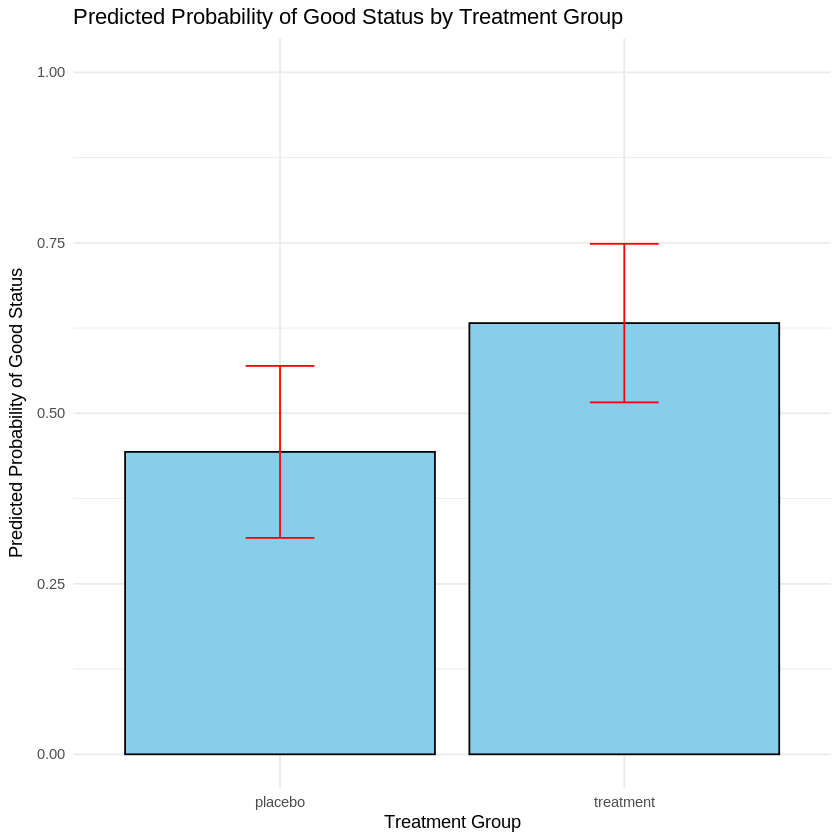

In [22]:
library(ggplot2)

# Create the bar plot
ggplot(treatment_summary, aes(x = treatment, y = mean_predicted_prob)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black") +
  geom_errorbar(aes(ymin = mean_predicted_prob - 1.96 * mean_se_prob,
                    ymax = mean_predicted_prob + 1.96 * mean_se_prob),
                width = 0.2, color = "red") +
  labs(x = "Treatment Group",
       y = "Predicted Probability of Good Status",
       title = "Predicted Probability of Good Status by Treatment Group") +
  theme_minimal() +
  ylim(0, 1) # Ensure y-axis is scaled from 0 to 1 for probabilities

## Visualize Month Effect

### Subtask:
Create a plot (e.g., a line plot or point plot with error bars) showing the predicted probabilities of 'good' status over different months, based on the generated predicted values.

#### Instructions
1. Aggregate the `new_data` DataFrame by `month` to calculate the mean `predicted_prob` and mean `se_prob` for each month. Store this aggregated data in a new DataFrame, for example, `month_summary`.
2. Create a line plot using `month_summary`, where the x-axis represents `month` and the y-axis represents the mean `predicted_prob`.
3. Add error bars or a shaded ribbon to the plot using the mean `se_prob` from `month_summary`.
4. Label the x-axis as 'Month', the y-axis as 'Predicted Probability of Good Status', and give the plot a title such as 'Predicted Probability of Good Status Over Months'.
5. Display the plot.

**Reasoning**:
To visualize the month effect, I will aggregate the `new_data` DataFrame by `month` to calculate the mean predicted probability and its standard error for each month, which is the first step outlined in the instructions for the 'Visualize Month Effect' subtask.



In [23]:
library(dplyr)

month_summary <- new_data %>%
  group_by(month) %>%
  summarise(mean_predicted_prob = mean(predicted_prob),
            mean_se_prob = mean(se_prob),
            .groups = 'drop')

print(month_summary)

# A tibble: 5 × 3
  month mean_predicted_prob mean_se_prob
  <ord>               <dbl>        <dbl>
1 0                   0.449       0.0629
2 1                   0.585       0.0613
3 2                   0.540       0.0617
4 3                   0.585       0.0612
5 4                   0.531       0.0620


**Reasoning**:
Now that the `month_summary` data frame has been created, I will use `ggplot2` to create a line plot showing the mean predicted probabilities over months, along with a shaded ribbon representing the 95% confidence interval, as instructed.



`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


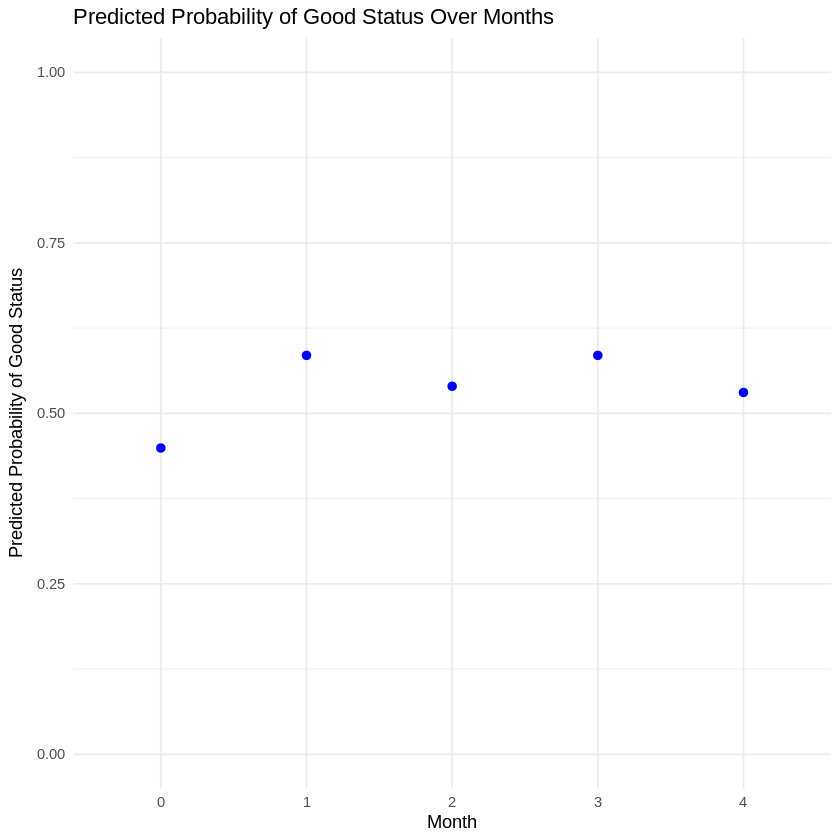

In [24]:
library(ggplot2)

# Create the line plot with a shaded ribbon for confidence intervals
ggplot(month_summary, aes(x = month, y = mean_predicted_prob)) +
  geom_line(color = "blue", linewidth = 1) +
  geom_ribbon(aes(ymin = mean_predicted_prob - 1.96 * mean_se_prob,
                    ymax = mean_predicted_prob + 1.96 * mean_se_prob),
              fill = "blue", alpha = 0.2) +
  geom_point(color = "blue", size = 2) + # Add points to highlight specific months
  labs(x = "Month",
       y = "Predicted Probability of Good Status",
       title = "Predicted Probability of Good Status Over Months") +
  theme_minimal() +
  ylim(0, 1) # Ensure y-axis is scaled from 0 to 1 for probabilities

**Reasoning**:
The previous code produced a warning about `geom_line()` having only one observation per group, which can be resolved by explicitly mapping all points to a single group using `group = 1` in the `aes` function. This clarifies to `ggplot2` that all data points should be connected to form a single line, thus preventing the warning.



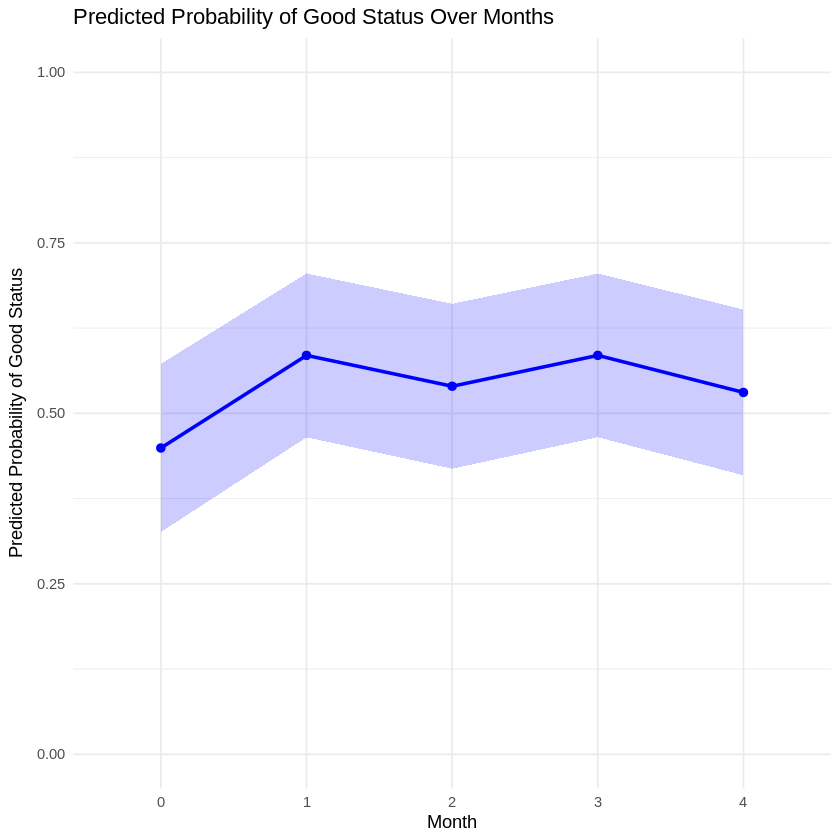

In [25]:
library(ggplot2)

# Create the line plot with a shaded ribbon for confidence intervals
ggplot(month_summary, aes(x = month, y = mean_predicted_prob, group = 1)) + # Added group = 1
  geom_line(color = "blue", linewidth = 1) +
  geom_ribbon(aes(ymin = mean_predicted_prob - 1.96 * mean_se_prob,
                    ymax = mean_predicted_prob + 1.96 * mean_se_prob),
              fill = "blue", alpha = 0.2) +
  geom_point(color = "blue", size = 2) + # Add points to highlight specific months
  labs(x = "Month",
       y = "Predicted Probability of Good Status",
       title = "Predicted Probability of Good Status Over Months") +
  theme_minimal() +
  ylim(0, 1) # Ensure y-axis is scaled from 0 to 1 for probabilities

## Final Task

### Subtask:
Summarize the key findings from the visualizations, highlighting the impact of treatment and month on the outcome, and discuss any further implications or potential next steps in the analysis.


## Summary:

### Data Analysis Key Findings

*   **Treatment Effect:** The 'treatment' group showed a substantially higher predicted probability of 'good' status (approximately 0.632) compared to the 'placebo' group (approximately 0.443). Both predictions were associated with similar standard errors (around 0.059-0.064).
*   **Month Effect:** The predicted probability of 'good' status varied across months. It started at approximately 0.449 in Month 0, increased to a peak around 0.585 in Month 1, slightly decreased to 0.540 in Month 2, rose again to 0.585 in Month 3, and then marginally decreased to 0.531 in Month 4. The standard errors for these predictions were consistently around 0.061-0.063.

### Insights or Next Steps

*   The treatment appears to have a positive and significant effect on achieving 'good' status, as the predicted probability for the treatment group is markedly higher than for the placebo group.
*   Further analysis could explore the interaction between `treatment` and `month` to understand if the treatment's efficacy changes over time, or if certain months are more responsive to treatment than others.
